In [3]:
#Importacion ded librerias
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import os 

#Librerías para clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import single, cophenet
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

## EDA

In [5]:
#Import dataset
os.chdir(r"\Users\DAY\Desktop\DIPLOMADO_ANALISIS_DE_DATOS")

df=pd.read_csv("CC_GENERAL.csv")
df.tail(3)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8947,C19188,23.398673,0.833333,144.40,0.00,144.4,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.0,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [6]:
#Forma del dataset de datos
df.shape

(8950, 18)

In [7]:
#Tipos de datos
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [8]:
#Informacion sobre el dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
#Estadisticas de cada campo
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [10]:
#Cuenta el numero de ceros por cada columna
#Esto se hizo porque en algunas de ellas el minimo es 0
df[df==0].count() / df.count()

CUST_ID                             0.000000
BALANCE                             0.008939
BALANCE_FREQUENCY                   0.008939
PURCHASES                           0.228380
ONEOFF_PURCHASES                    0.480670
INSTALLMENTS_PURCHASES              0.437542
CASH_ADVANCE                        0.517095
PURCHASES_FREQUENCY                 0.228268
ONEOFF_PURCHASES_FREQUENCY          0.480670
PURCHASES_INSTALLMENTS_FREQUENCY    0.437430
CASH_ADVANCE_FREQUENCY              0.517095
CASH_ADVANCE_TRX                    0.517095
PURCHASES_TRX                       0.228380
CREDIT_LIMIT                        0.000000
PAYMENTS                            0.026816
MINIMUM_PAYMENTS                    0.000000
PRC_FULL_PAYMENT                    0.659553
TENURE                              0.000000
dtype: float64

In [11]:
df.head(4)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12


In [12]:
#Non unique values per each one of the columns
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [13]:
#Busca valores nulos en el dataset
print("Existen ", df.isnull().sum().sum(), "valores nulos")

Existen  314 valores nulos


In [14]:
#Muestra las columnas que no tienen cero, es decir, las que tienen los valores nulos
print(df.columns[df.isnull().any()])

Index(['CREDIT_LIMIT', 'MINIMUM_PAYMENTS'], dtype='object')


In [15]:
#Busca duplicados
print("Duplicate records:" )
print(df[df.duplicated()])

Duplicate records:
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


In [16]:
(df.isnull().sum() / len(df)) * 100

CUST_ID                             0.000000
BALANCE                             0.000000
BALANCE_FREQUENCY                   0.000000
PURCHASES                           0.000000
ONEOFF_PURCHASES                    0.000000
INSTALLMENTS_PURCHASES              0.000000
CASH_ADVANCE                        0.000000
PURCHASES_FREQUENCY                 0.000000
ONEOFF_PURCHASES_FREQUENCY          0.000000
PURCHASES_INSTALLMENTS_FREQUENCY    0.000000
CASH_ADVANCE_FREQUENCY              0.000000
CASH_ADVANCE_TRX                    0.000000
PURCHASES_TRX                       0.000000
CREDIT_LIMIT                        0.011173
PAYMENTS                            0.000000
MINIMUM_PAYMENTS                    3.497207
PRC_FULL_PAYMENT                    0.000000
TENURE                              0.000000
dtype: float64

In [17]:
#Imputación de nulos con la mediana
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [18]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [19]:
#SE elimina el "CUST_ID" porque es diferente para cada cliente
df = df.drop("CUST_ID", axis=1)

In [20]:
(df == 0).sum() / len(df)

BALANCE                             0.008939
BALANCE_FREQUENCY                   0.008939
PURCHASES                           0.228380
ONEOFF_PURCHASES                    0.480670
INSTALLMENTS_PURCHASES              0.437542
CASH_ADVANCE                        0.517095
PURCHASES_FREQUENCY                 0.228268
ONEOFF_PURCHASES_FREQUENCY          0.480670
PURCHASES_INSTALLMENTS_FREQUENCY    0.437430
CASH_ADVANCE_FREQUENCY              0.517095
CASH_ADVANCE_TRX                    0.517095
PURCHASES_TRX                       0.228380
CREDIT_LIMIT                        0.000000
PAYMENTS                            0.026816
MINIMUM_PAYMENTS                    0.000000
PRC_FULL_PAYMENT                    0.659553
TENURE                              0.000000
dtype: float64

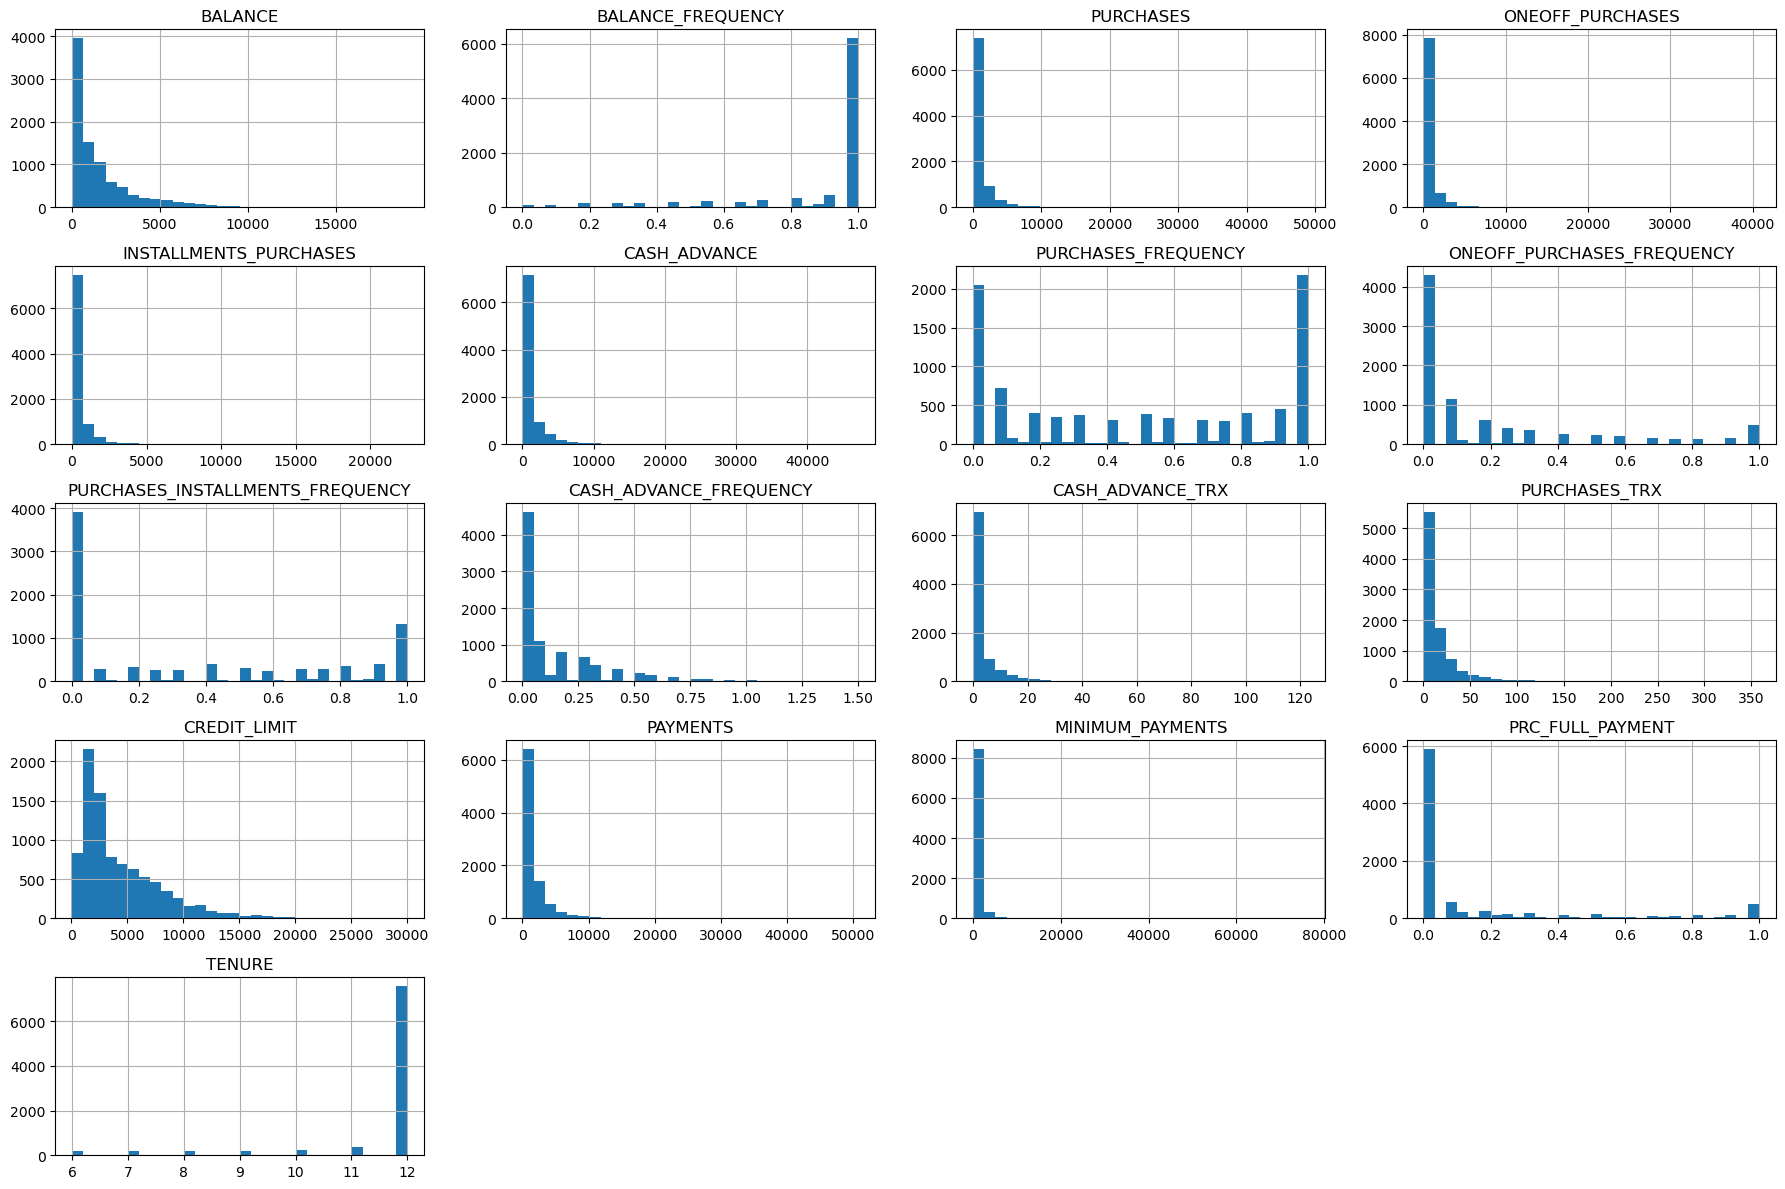

In [21]:
#Visualización del EDA
df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

# Feature Engineering

In [22]:
#Creación de nuevas variables
#TOTAL_PURCHASES_TYPES
#Suma compras de una sola exhibición + compras a plazos. Ayuda a resumir comportamiento de compra.
df["TOTAL_PURCHASES_TYPES"] = (df["ONEOFF_PURCHASES"] + df["INSTALLMENTS_PURCHASES"])

#PAYMENT_TO_MIN_RATIO
#Compara cuánto paga el cliente contra su pago mínimo (alto = paga bastante más del mínimo, cercano a 1 = paga cerca del mínimo,bajo = paga poco respecto al mínimo)
df["PAYMENT_TO_MIN_RATIO"] = df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1)

#BALANCE_TO_LIMIT_RATIO
#Mide qué tan usado está el límite de crédito (alto = usa gran parte del crédito, bajo = usa poco)
df["BALANCE_TO_LIMIT_RATIO"] = df["BALANCE"] / (df["CREDIT_LIMIT"] + 1)

In [23]:
df.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_PURCHASES_TYPES,PAYMENT_TO_MIN_RATIO,BALANCE_TO_LIMIT_RATIO
0,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12,95.4,1.436214,0.04086
1,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0.0,3.822677,0.45743


In [24]:
#Hacemos copia del dataframe
df2 = df.copy()

In [25]:
#Estandarización de variables
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df2)

### Elbow plot

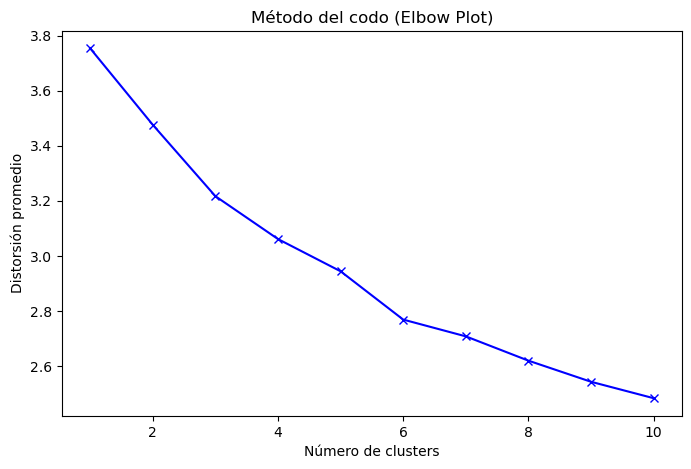

In [27]:
#Buscando el número óptimo de clústers
clusters = range(1, 11)
mean_distortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)
    
    distortion = sum(np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1)) / df_scaled.shape[0]
    
    mean_distortions.append(distortion)

plt.figure(figsize=(8,5))
plt.plot(clusters, mean_distortions, "bx-")
plt.xlabel("Número de clusters")
plt.ylabel("Distorsión promedio")
plt.title("Método del codo (Elbow Plot)")
plt.show()

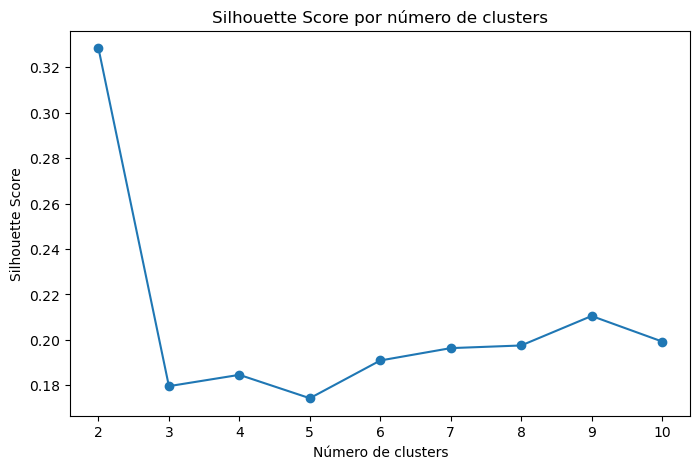

In [28]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=15)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.show()

In [29]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init=15)
df2["Cluster"] = kmeans.fit_predict(df2)

In [30]:
#S pueden ver las coordenadas de los centroides para cada variable
centroids= kmeans.cluster_centers_
centroids

array([[8.54900002e+02, 8.53906955e-01, 5.88235256e+02, 3.02699873e+02,
        2.85833757e+02, 4.98137599e+02, 4.65322767e-01, 1.52610458e-01,
        3.50398046e-01, 1.06782395e-01, 2.25401929e+00, 1.05138570e+01,
        2.76066048e+03, 9.83622402e+02, 5.63891444e+02, 1.56145909e-01,
        1.14337774e+01, 5.88533630e+02, 5.33504232e+00, 3.81728038e-01],
       [4.57175826e+03, 9.57342664e-01, 1.17481762e+04, 8.27198294e+03,
        3.47634713e+03, 3.47414913e+03, 8.65691888e-01, 7.04017224e-01,
        6.85565965e-01, 1.57713476e-01, 6.52447552e+00, 9.56013986e+01,
        1.21468531e+04, 1.55505323e+04, 2.81777679e+03, 3.58851231e-01,
        1.18881119e+01, 1.17483301e+04, 2.12628197e+01, 3.76688404e-01],
       [3.41165921e+03, 9.39282368e-01, 1.51886186e+03, 9.41339209e+02,
        5.77837219e+02, 2.20156260e+03, 5.38585446e-01, 3.13981944e-01,
        3.84546852e-01, 2.15110609e-01, 5.89762742e+00, 2.16678383e+01,
        8.98811711e+03, 3.01576162e+03, 1.52732797e+03, 1.3384

In [32]:
#Revisión de cuantos registros hay en cada cluster
df2["Cluster"].value_counts()

Cluster
0    6531
2    2276
1     143
Name: count, dtype: int64

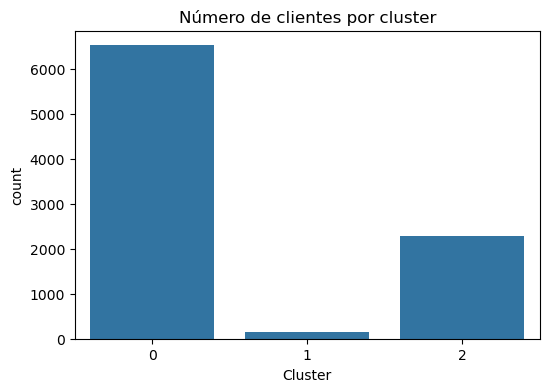

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="Cluster", data=df2)
plt.title("Número de clientes por cluster")
plt.show()

In [34]:
cluster_profile = df2.groupby("Cluster").mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_PURCHASES_TYPES,PAYMENT_TO_MIN_RATIO,BALANCE_TO_LIMIT_RATIO
Cluster,,,,,,,,,,,,,,,,,,,,
0,854.900002,0.853907,588.235256,302.699873,285.833757,498.137599,0.465323,0.152610,0.350398,0.106782,2.254019,10.513857,2760.660479,983.622402,563.891444,0.156146,11.433777,588.533630,5.335042,0.381728
1,4571.758262,0.957343,11748.176224,8271.982937,3476.347133,3474.149128,0.865692,0.704017,0.685566,0.157713,6.524476,95.601399,12146.853147,15550.532258,2817.776794,0.358851,11.888112,11748.330070,21.262820,0.376688
2,3411.659210,0.939282,1518.861863,941.339209,577.837219,2201.562596,0.538585,0.313982,0.384547,0.215111,5.897627,21.667838,8988.117111,3015.761624,1527.327969,0.133849,11.733743,1519.176428,8.484940,0.409314


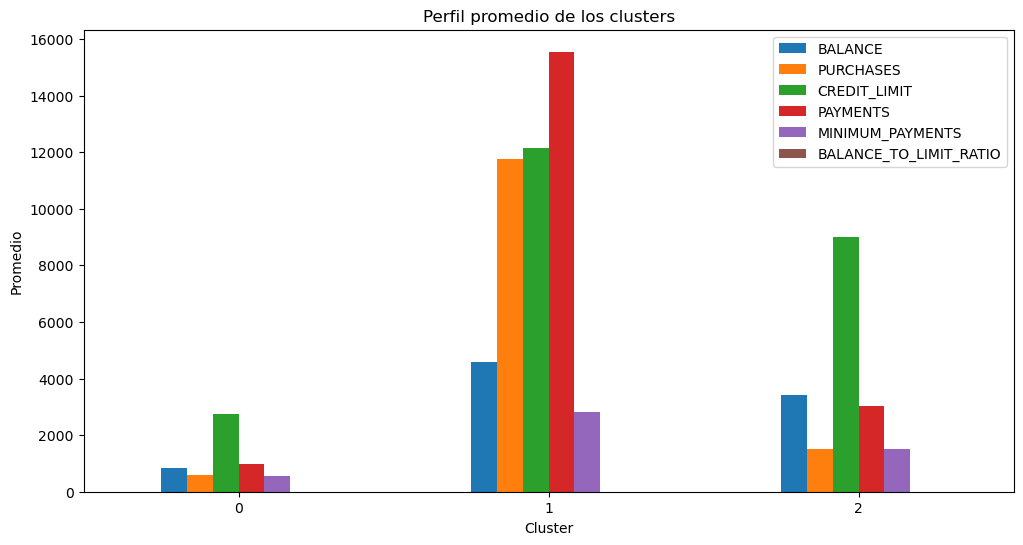

In [35]:
variables_clave = ["BALANCE","PURCHASES","CREDIT_LIMIT","PAYMENTS","MINIMUM_PAYMENTS","BALANCE_TO_LIMIT_RATIO"]

cluster_profile[variables_clave].plot(kind="bar", figsize=(12,6))
plt.title("Perfil promedio de los clusters")
plt.ylabel("Promedio")
plt.xticks(rotation=0)
plt.show()

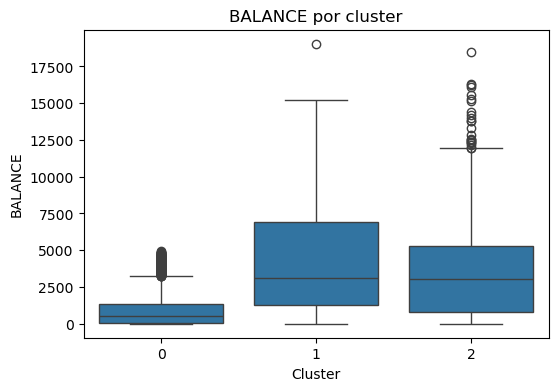

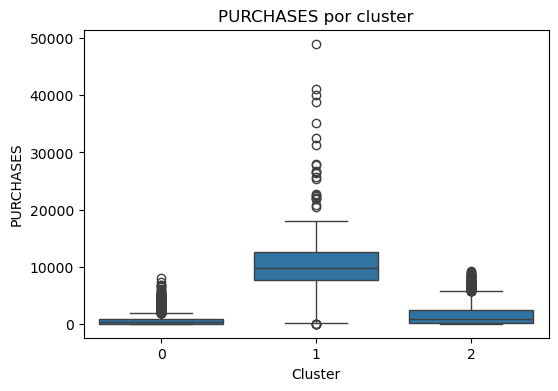

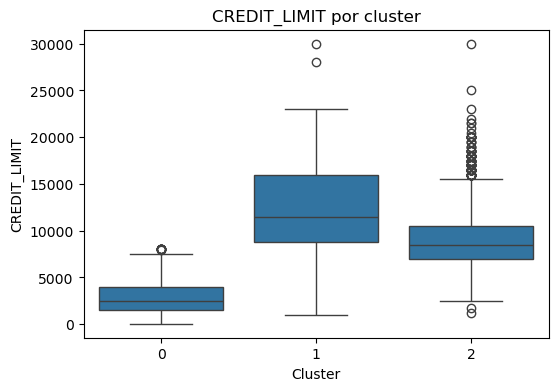

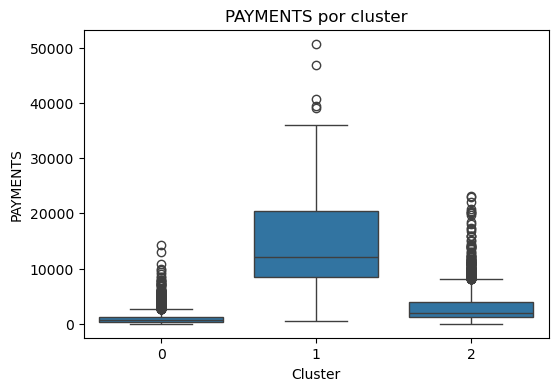

In [37]:
variables_box = ["BALANCE", "PURCHASES", "CREDIT_LIMIT", "PAYMENTS"]

for var in variables_box:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Cluster", y=var, data=df2)
    plt.title(f"{var} por cluster")
    plt.show()

## Dendograma

In [39]:
#Creamos una muestra para no saturar el dendograma
sample_df = df2.sample(500, random_state=1)

In [40]:
#Usamos ward para reducir la varianza
Z = linkage(sample_df, method="ward")

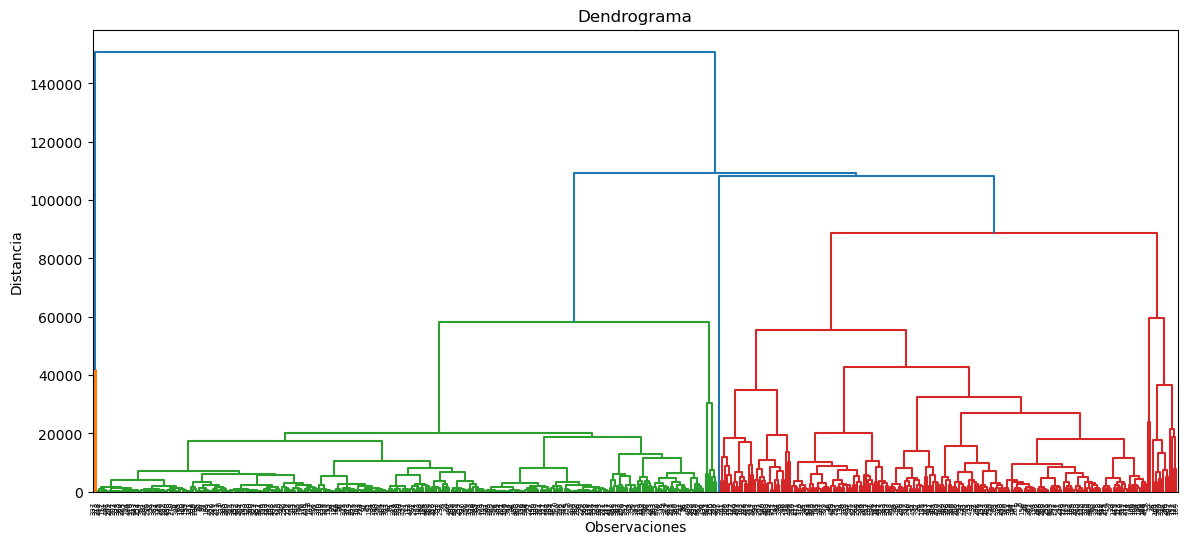

In [43]:
plt.figure(figsize=(14,6))
dendrogram(Z)
plt.title("Dendrograma")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

In [44]:
cluster_profile.T

Cluster,0,1,2
BALANCE,854.900002,4571.758262,3411.659210
BALANCE_FREQUENCY,0.853907,0.957343,0.939282
PURCHASES,588.235256,11748.176224,1518.861863
ONEOFF_PURCHASES,302.699873,8271.982937,941.339209
INSTALLMENTS_PURCHASES,285.833757,3476.347133,577.837219
CASH_ADVANCE,498.137599,3474.149128,2201.562596
PURCHASES_FREQUENCY,0.465323,0.865692,0.538585
ONEOFF_PURCHASES_FREQUENCY,0.152610,0.704017,0.313982
PURCHASES_INSTALLMENTS_FREQUENCY,0.350398,0.685566,0.384547
CASH_ADVANCE_FREQUENCY,0.106782,0.157713,0.215111


### Conclusión
- A partir del análisis exploratorio se identificó que el dataset presenta información financiera relevante para segmentar clientes de tarjetas de crédito, aunque fue necesario imputar valores nulos en las variables CREDIT_LIMIT y MINIMUM_PAYMENTS. También se eliminó la variable CUST_ID, ya que únicamente funciona como identificador y no aporta valor al modelo.
- Posteriormente, se realizó estandarización de variables y se aplicó el algoritmo K-Means para segmentar a los clientes. Con apoyo del método del codo, el silhouette score y el dendrograma, se determinó que una segmentación de 3 clusters era la adecuada.
- Los resultados muestran tres perfiles principales de clientes: un grupo mayoritario con uso moderado o bajo de la tarjeta, un grupo intermedio con mayor actividad financiera, y un grupo pequeño de clientes altamente activos con mayores niveles de compras, pagos, balance y límite de crédito.
- En conjunto, el modelo permitió identificar patrones diferenciados de comportamiento financiero, lo que puede ser útil para futuras estrategias.